# Evaluating and Extending an RNN-based Part-of-Speech Tagger

This notebook implements and evaluates several extensions to a recurrent neural network pipeline for Part-of-Speech tagging using Universal Dependencies datasets. The objective is to analyze how different architectural and training choices affect tagging performance across languages with different morphological properties.



---



## Computational Considerations

Running the full experimental pipeline in this notebook can be expensive.  
The experiments evaluate multiple model configurations (LSTM vs GRU, bidirectional vs unidirectional RNNs, dropout settings, masking augmentation, and tagset variations) across several languages from the Universal Dependencies project. Each configuration requires training and evaluating a neural network, which increases runtime substantially when all combinations are executed sequentially (despite not all languages being analyzed for all issues).

Another factor affecting runtime is the **size of the datasets for each language**. Some languages in the Universal Dependencies collection contain significantly more sentences than others, resulting in a larger number of training batches and longer training times. For example, languages with larger corpora (Russian) produce more stable training dynamics but require more computational resources, while smaller datasets train faster but may produce more variable or less reliable results.

This difference in dataset size can also influence model performance comparisons. Larger datasets generally allow the model to learn more robust representations, whereas smaller datasets may lead to higher variance in evaluation metrics. Because of this imbalance, comparisons across languages should be interpreted with some caution.

For future work, a more controlled experimental setup could improve fairness between languages. Possible strategies include limiting training data to equal sized subsets or applying better hyperparameter tuning for each dataset. These approaches could help produce more stable and directly comparable results across languages.

## Notebook Structure

The following sections describe the different elements of the pipeline and the experiments performed.

### 1. Installing and Imports
This section installs required libraries and imports all Python packages used throughout the notebook, including PyTorch, data handling utilities, and visualization libraries, also here the Universal Dependencies datasets are loaded and parsed. The `.conllu` files are processed to extract sentences and their corresponding POS tags,

### 2. Data Handling
This section implements the static `Datahandling` class, which prepares the linguistic data for model training.  
The class includes several static methods responsible for transforming the raw dataset into numerical tensors suitable for neural network input.

The main steps include:

• **Loading the data** – extracting tokens and their corresponding Universal POS tags (UPOS) from the training portion of the dataset and pairing them together.

• **Cleaning the data** – filtering out very short sentences and separating the tokens (`X`) from their corresponding POS tags (`y`).

• **Splitting the dataset** – dividing the sentences into training and test sets.

• **Building vocabularies** – constructing mappings from tokens and tags to numerical indices (`token2idx`, `tag2idx`). Special tokens such as `<UNK>` for unknown words, and `<PAD>` for sequence padding are added.

• **Padding and encoding** – converting sentences and tag sequences into padded PyTorch tensors of equal length, replacing unseen words with `<UNK>` and ensuring compatibility with batch training.

### 3. Dataset and DataLoader
This section implements a PyTorch `Dataset` class and later implements the `DataLoader`. It converts tokens and tags into numerical indices, handles padding, and allows efficient batching during training without the need of a manual batching

### 4. RNN Model
The neural architecture used for POS tagging is defined here. The model includes embedding layers and recurrent layers (LSTM or GRU) and supports configurable parameters such as hidden size, bidirectionality and dropout.

### 5. Individual Data
This section prepares the datasets for one individual language as a visualization how it works for the rest of languages. To observe its lenght and individual simple performance

### 6. Multiple Languages Experiment Run
Here the training pipeline is executed across multiple languages. The model is trained and evaluated on several UD datasets in order to compare performance across languages with different linguistic properties.

### 7. Dropout
This experiment evaluates the impact of dropout as a regularization technique. Two Different dropout rates are tested to observe their effect on model performance and generalization with the use of the three best performing languages.

### 8. Masking
This section introduces randomly masking tokens during training. The goal is to encourage the model to rely more on contextual information instead of than memorizing specific associations.

### 9. XPOS vs UPOS
The model is evaluated using both Universal POS tags (UPOS) and language-specific POS tags (XPOS). This experiment explores how tagset can influence tagging accuracy.

### 10. Experiment & Original Pipeline
This section runs one full experimental pipeline in a mixed dataset en + sp. In addition here we get to observe how vectors are positioned in the vector space and their syntactic relationship, and a small semantic representation.

### 11. Table Results
All experiment outputs are aggregated into a results table summarizing the performance of each configuration across languages and model variations.

### 12. Results Analysis
This section analyzes the quantitative results. Differences between languages, architectural choices, and experimental settings are discussed using the results obtained in the previous section.

### 13. Discussion
The final section reflects on the assignment, discussing implementation challenges, computational considerations, model behavior across languages, and the educational insights gained from the experiments.

##1. Installing and Imports


In [2]:
pip install datasets==2.19.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [3]:
pip install conllu

In [4]:
# Our standard imports for maths and basic methodology
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import random

# For user feedback visualization and saving data
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt

# Imports for pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader ### Need TODO

# Import for obtaining the dataset, using huggingface
from datasets import load_dataset, concatenate_datasets

In [5]:
# we will assign a variable to each of the languages that we are going to examinate:
# and we add them to a dictionary to be able to run it later so we can examine the results

lan = {"en" : load_dataset("universal_dependencies", "en_ewt"),                 # English
       "sp" : load_dataset("universal_dependencies", "es_gsd"),                 # Spanish
       "ru" : load_dataset("universal_dependencies", "ru_syntagrus"),           # Russian
       "sv" : load_dataset("universal_dependencies", "sv_talbanken"),           # Swedish
       "eu" : load_dataset("universal_dependencies", "eu_bdt"),                 # Basque
       "zh" : load_dataset("universal_dependencies", "zh_gsd"),                 # Chinese
       "fi" : load_dataset("universal_dependencies", "fi_tdt"),                 # Finnish
       "tr" : load_dataset("universal_dependencies", "tr_imst"),                # Turkish
       "ja":  load_dataset("universal_dependencies", "ja_gsd"),                 # Japanese
       "la" : load_dataset("universal_dependencies", "la_proiel")               # Latin
       }


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/datasets/load.py:1486: FutureWarning: The repository for universal_dependencies contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/universal_dependencies
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets

Generating train split:   0%|          | 0/12543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2002 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2077 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/14187 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/501 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/543 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/15917 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1234 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1260 [00:00<?, ? examples/s]

In [6]:
# Small test to see how the sentences are computed and to get the values upos and xpos
# to take into account the values of upos are numerical as the Neural Network requires it

sp_sentence = lan["sp"]["train"][0]
zh_sentence = lan["zh"]["train"][0]
eu_sentence = lan["eu"]["train"][0]


print("Example of one sentence in Spanish:", sp_sentence)
print("Example of one sentence in Chinese:", zh_sentence)
print("Example of one sentence in Basque:", eu_sentence)

Example of one sentence in Spanish: {'idx': 'es-train-001-s1', 'text': 'Además se le pediría a las empresas interesadas en prestar el servicio que se hagan cargo de la señalización y la cartelería que contiene información para los usuarios.', 'tokens': ['Además', 'se', 'le', 'pediría', 'a', 'las', 'empresas', 'interesadas', 'en', 'prestar', 'el', 'servicio', 'que', 'se', 'hagan', 'cargo', 'de', 'la', 'señalización', 'y', 'la', 'cartelería', 'que', 'contiene', 'información', 'para', 'los', 'usuarios', '.'], 'lemmas': ['además', 'él', 'él', 'pedir', 'a', 'el', 'empresa', 'interesado', 'en', 'prestar', 'el', 'servicio', 'que', 'él', 'hacer', 'cargo', 'de', 'el', 'señalización', 'y', 'el', 'cartelería', 'que', 'contener', 'información', 'para', 'el', 'usuario', '.'], 'upos': [14, 11, 11, 16, 2, 8, 0, 6, 2, 16, 8, 0, 5, 11, 16, 0, 2, 8, 0, 9, 8, 0, 5, 16, 0, 2, 8, 0, 1], 'xpos': [None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None

##2. Data Handling

In [7]:
"""
In order to make a better structured and easier model call for the loop I decided
to introduce a full static class so we can compute easier the data extraction of
each language and dont require so much manual work, I decided to keep it statical
as that would allow me more freedom without needing to refactor the whole data
extraction and padding process.
"""


class Datahandling:

  @staticmethod
  def load_data(dataset):
    values = []
    for sentence in dataset["train"]:
      token = sentence["tokens"]
      tags = sentence["upos"]

        # we are saving both values together
      union = list(zip(token,tags))
      values.append(union)

    return values

  @staticmethod
  def clean_data(values):
    # we make sure that sentences are relevant for the study and separate X and y

    sentences = values
    sentences = [sentence for sentence in sentences if len(sentence) > 2]

    assert len(sentences) > 0
    assert len(sentences[0]) > 2

    X = [[token for token, tag in sentence] for sentence in sentences]
    y = [[tag for token, tag in sentence] for sentence in sentences]

    assert len(X) == len(y)

    return X,y

  @staticmethod
  def split_data(X,y):
    # we get our trains and test data

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

    assert len(X_train) == len(y_train)
    assert len(X_test) == len(y_test)
    assert len(X_train)+len(X_test) == len(X)

    return X_train, X_test, y_train, y_test


  @staticmethod
  def get_vocabulary(X_train, y_train):

    # We printed part of the vocabulary to make sure the word to index mapping was created correctly and contains real tokens from the training data.

    tokens = {token for sentence in X_train for token in sentence}
    idx2token = list(tokens)
    idx2token.insert(0, '<UNK>')
    idx2token.append('<PAD>')
    token2idx = {token:idx for idx, token in enumerate(idx2token)}

    tags = {tag for tags in y_train for tag in tags}
    idx2tag = list(tags)
    idx2tag.append('<PAD>')
    tag2idx = {tag:idx for idx, tag in enumerate(idx2tag)}

    return token2idx, idx2token, tag2idx, idx2tag

  @staticmethod
  def pad_and_encode(sentences, labels, token2idx, tag2idx ):
    # This would help us have the lenght of our sentences in equal size for the tensors to work

    assert len(sentences)==len(labels)
    assert np.all([len(sentence)==len(tags) for sentence, tags in zip(sentences, labels)])

    max_sentence_length = np.max([len(sentence) for sentence in sentences])
    padded_sentences = torch.zeros(len(sentences), max_sentence_length,         # Create data structures with <PAD> as default
                                  dtype=torch.long)
    padded_sentences[:] = token2idx['<PAD>']
    padded_labels = torch.zeros(len(sentences), max_sentence_length,
                                dtype=torch.long)
    padded_labels[:] = tag2idx['<PAD>']

    # Encode tokens and tags into indices replacing unknown tokens with <UNK>
    for i, (sentence, tags) in enumerate(zip(sentences, labels)):               # Loop over the data
      for j, token in enumerate(sentence):
        if token in token2idx.keys():
          padded_sentences[i, j] = token2idx[token]
        else:
          padded_sentences[i, j] = token2idx['<UNK>']
      for j, tag in enumerate(tags):
        padded_labels[i, j] = tag2idx[tag]

    return padded_sentences, padded_labels


## 3. Dataset and Dataloader

In [8]:
class lanextdataset(Dataset):

  # we follow the standard description of the manual, I indeed followed the RTFM,
  # struggling to understand exacly how to properly implement the dataloader.

  def __init__(self, padded_sentences, padded_labels):
    self.padded_sentences = padded_sentences
    self.padded_labels = padded_labels

  def __len__(self):
    return len(self.padded_sentences)

  def __getitem__(self, idx):
    sentence = self.padded_sentences[idx]
    labels = self.padded_labels[idx]
    return sentence, labels


## 4. RNN Model

In [ ]:
# the extension is facilitated by nn, which already covers for nn.gru, which is really helpful
class RNNTagger(nn.Module):
  # Models to exchange in model_type: "lstm" , "gru"
  def __init__(self, word_embedding_dim, hidden_dim, vocabulary_size, tagset_size, dropout = 0.0, model_type = "lstm", bidirectional = False): # we will change the model we want to use here

    """
    An LSTM / GRU based tagger / RNN tagger

    word_embedding_dim:
      The dimensionality of the word embedding
    lstm_hidden_dim:
      The dimensionality of the hidden state in the LSTM
    vocabulary_size:
      The number of unique tokens in the word embedding (including <PAD> etc)
    tagset_size:
      The number of unique POS tags (not including <PAD>, as we don't want to predict it)
    Dropout:
      The amount of neurons from the model that we 'turn off' so the model learns more to
      check contextuality.
    Model_type:
      to change the model when we run it just as simple as manually adjusting it on the model call
    Bidirectional:
      to change the model to be unidirectional or bidirectional so it does the forwad pass d = 1 or forward and back d = 2
    """

    super(RNNTagger, self).__init__()


    # We need to initialise the class we are inheriting from
    self.hidden_dim_ = hidden_dim
    self.bidirectional = bidirectional
    self.dropout = dropout
    # this is the way that dropout is implememted in the manual
    self.m = nn.Dropout(p=dropout)

    self.model_type = model_type # to remember the type of model

    # here we just assign the directionality that we want our model to take
    if self.bidirectional == False:
      D = 1
    elif self.bidirectional == True:
      D = 2


                                                                                # This simply stores the parameters
    self.vocabulary_size_ = vocabulary_size
    self.tagset_size_ = tagset_size


    self._word_embedding = nn.Embedding(num_embeddings=vocabulary_size,         # Creates the vector space for the input words
                                         embedding_dim=word_embedding_dim,
                                         padding_idx=token2idx['<PAD>'])


    # Here we add the branching for the model to have the two possibilities, that we will chose from
    # also we need to assign if we want bidirectionality or not giving it true or false

    if model_type == "lstm":
      self._rnn = nn.LSTM(input_size=word_embedding_dim,                        # The LSTM takes an embedded sentence as input, and outputs
                         hidden_size=hidden_dim,                                # vectors with dimensionality lstm_hidden_dim.
                         batch_first=True, bidirectional = self.bidirectional)
    elif model_type == "gru":
      self._rnn = nn.GRU(input_size=word_embedding_dim,                         # GRU takes an embedded sentence as input, and outputs
                         hidden_size=hidden_dim,                                # vectors with dimensionality Gru_hidden_dim.
                         batch_first=True, bidirectional = self.bidirectional)



    self._fc = nn.Linear(hidden_dim * D, tagset_size)                           # The linear layer maps from the RNN output space to tag space
    self._softmax = nn.LogSoftmax(dim=1)                                        # Softmax of outputting PDFs over tags

    self.training_loss_ = list()                                                # For plotting
    self.training_accuracy_ = list()

    if torch.cuda.is_available():                                               # Move the model to the GPU (if we have one)
      self.cuda()

  def forward(self, padded_sentences):
    """The forward pass through the network"""
    batch_size, max_sentence_length = padded_sentences.size()

    embedded_sentences = self._word_embedding(padded_sentences)                 # Sentences encoded as integers are mapped to vectors
    dropout_embedded = self.m(embedded_sentences)                               # Dropout is applied to the matrix space of the embbeded values

    sentence_lengths = (padded_sentences!=token2idx['<PAD>']).sum(dim=1)        # Find the length of sentences
    sentence_lengths = sentence_lengths.long().cpu()                            # Ensure the correct format
    X = nn.utils.rnn.pack_padded_sequence(dropout_embedded, sentence_lengths,   # Pack the embedded data
                                          batch_first=True, enforce_sorted=False)
    rnn_out, _ = self._rnn(X)                                                   # Run the RNN layer
    X, _ = nn.utils.rnn.pad_packed_sequence(rnn_out, batch_first=True,total_length=max_sentence_length) # Unpack the output from the RNN ,
                                                                                # we need the total lenght to match the padding
                                                                                # otherwise we get a problem of missmatch within the space

    X = X.contiguous().view(-1, X.shape[2])                                     # The output from the RNN layer is flattened
    dropout_hidden = self.m(X)                                                  # Dropout is applied to the flattened output
    tag_space = self._fc(dropout_hidden )                                       # Fully connected layer

    tag_scores = self._softmax(tag_space)                                       # Softmax is applied to normalise the outputs
    return tag_scores.view(batch_size, max_sentence_length, self.tagset_size_)


  def fit(self):
    loss_function = nn.NLLLoss(ignore_index=tag2idx['<PAD>'])                   # A loss function that fits our choice of output layer and data. The
                                                                                # loss function will ignore the padding index in the targets.
    optimizer = torch.optim.Adam(self.parameters(), lr=0.01)                    # We give the optimiser the parameters to work with, note that we can choose to only give some parameters

    for epoch in range(10):                                                          # Times to loop over the full dataset
      with tqdm(dataloader, total=len(dataloader)) as batches:
        for inputs, targets in batches:                                            # Loop once over the training data
          self.zero_grad()                                                         # Reset gradients
          scores = self(inputs)                                                    # Forward pass
          loss = loss_function(scores.view(-1, self.tagset_size_),                 # Get loss, the data is reshaped as a long line of predictions and targets
                           targets.view(-1))
          loss.backward()                                                           # Backpropagate the error
          optimizer.step()                                                          # Run the optimizer to change the weights w.r.t the loss
          predictions = scores.argmax(dim=2)                                        # Calculate the batch training accuracy
          mask = targets!=tag2idx['<PAD>']                                          # Create a mask for ignoring <PAD> in the targets
          correct = (predictions[mask] == targets[mask]).sum().item()               # Item pulls the value from the GPU automatically (if needed)
          accuracy = correct / mask.sum().item()*100
          self.training_accuracy_.append(accuracy)                                 # Save the accuracy for plotting
          self.training_loss_.append(loss.item())                                  # Save the loss for plotting
          batches.set_postfix(loss=loss.item(), accuracy=accuracy)


  def score(self):
    with torch.no_grad():                                                           # Do not use the following forward passes to calculate a gradient
      n_correct = 0
      n_total = 0
      for inputs, targets in dataloader_test:                                       # Loop once over the test data
        scores = self(inputs)                                                       # Runs the test data through the model
        predictions = scores.argmax(dim=2)                                          # Finds the predictions
        mask = targets!=tag2idx['<PAD>']                                            # Create a mask for ignoring <PAD> in the targets
        n_correct += (predictions[mask] == targets[mask]).sum().item()              # Sums the number of correct predictions
        n_total += mask.sum().item()
      accuracy = 100 * n_correct / n_total
      return accuracy


##5. Individual Data

In [ ]:
dataset = lan["sp"]
sentences = Datahandling.load_data(dataset)
X, y = Datahandling.clean_data(sentences)
X_train, X_test, y_train, y_test = Datahandling.split_data(X, y)
token2idx, idx2token, tag2idx, idx2tag = Datahandling.get_vocabulary(X_train, y_train)
X_train_pad, y_train_pad = Datahandling.pad_and_encode(X_train, y_train, token2idx, tag2idx)
X_test_pad, y_test_pad = Datahandling.pad_and_encode(X_test, y_test, token2idx, tag2idx)

In [ ]:
print("Language:", "Spanish")
print("Training sentences:", len(X_train))
print("Test sentences:", len(X_test))
print("Example tokens:", X_train[0])
print("Example tags:", y_train[0])
print("Vocabulary sample:", idx2token[:15])
print("Tag:", idx2tag)
print("Encoded sentence:", X_train_pad[0])
print("Encoded tags:", y_train_pad[0])

Language: Spanish
Training sentences: 12763
Test sentences: 1419
Example tokens: ['Ficha', 'entonces', 'por', 'Cleveland', 'Cavaliers', ',', 'donde', 'corre', 'la', 'misma', 'suerte', '.']
Example tags: [16, 14, 2, 10, 10, 1, 14, 16, 8, 6, 0, 1]
Vocabulary sample: ['<UNK>', 'Westinghouse', 'fábulas', 'Agosto', 'llodos', 'E69', 'cuádruples', 'sofocantes', 'supremacía', 'digo', 'Scotiabank', 'Tolkien', '12/km', 'Cesarea', 'n.']
Tag: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, '<PAD>']
Encoded sentence: tensor([ 9032,  2334, 20298, 16709,  4027, 30152, 43874,  8897, 28211, 19477,
        26981, 43837, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023,
        44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023,
        44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023,
        44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023,
        44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023, 44023,
       

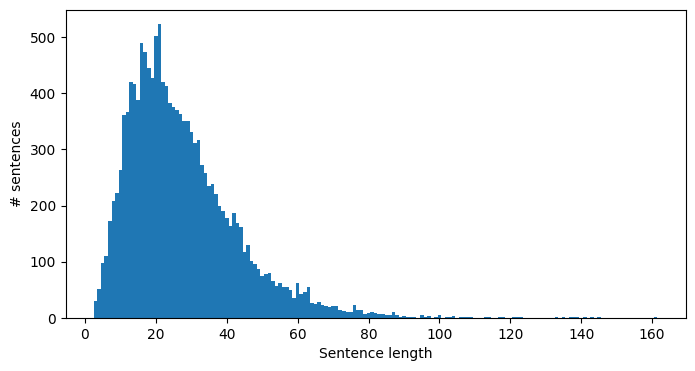

In [ ]:
l = np.asarray([len(x) for x in X], dtype=int)
plt.figure(figsize=(8, 4))
x = np.unique(l)
plt.bar(x, [np.sum(l==e) for e in x], width=1)
plt.xlabel("Sentence length")
plt.ylabel("# sentences")
plt.show()

In [ ]:
dataset = lanextdataset(X_train_pad,y_train_pad)
dataset_test = lanextdataset(X_test_pad,y_test_pad)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

model = RNNTagger(word_embedding_dim=32,
                  hidden_dim=64,
                  vocabulary_size=len(token2idx),
                  tagset_size=len(tag2idx)-1)
model.fit()
accuracy = model.score()
print("Test accuracy:", accuracy)

100%|██████████| 200/200 [00:35<00:00,  5.71it/s, accuracy=99.2, loss=0.0295]


Test accuracy: 91.47727272727273


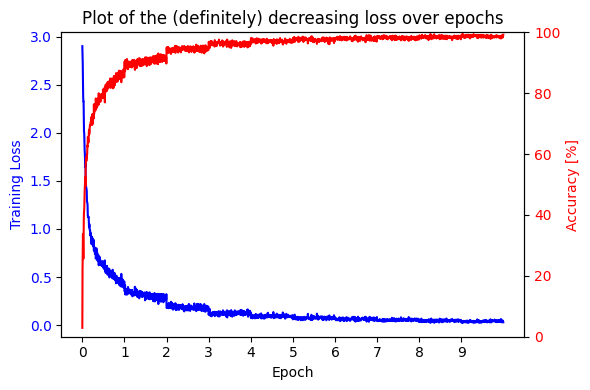

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (definitely) decreasing loss over epochs")
ax.plot(model.training_loss_, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Epoch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(model.training_accuracy_, 'r-')
ax.set_ylabel("Accuracy [%]", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 100
ax.axis(a)
batch_size = 64
t = np.arange(0, len(model.training_accuracy_), len(X_train)//batch_size+1)
ax.set_xticks(ticks=t)
ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

## 6.  Multiple Languages Experiment Run

In [ ]:
"""
Currently the model is set for the standard lstm unidirectional as it is the most optimal and fast for checking the model runability,
however the results that appear are the Gru Bidirectional, which is the last model I run.
"""

# create results only if it does not already exist, so we do not overwritte our table or lose it easily
if "results" not in globals():
    results = []

for language, datasets in lan.items():
    sentences = Datahandling.load_data(datasets)
    X,y = Datahandling.clean_data(sentences)
    X_train, X_test, y_train, y_test = Datahandling.split_data(X,y)

    """
    here we calculate the majority tag baseline for each language model, which i considered that could give a better result that purely random
    we would need to deactivate it once the first time is run
    """

    tag_counts = {}
    for tags in y_train:
      for tag in tags:
        if tag in tag_counts:
          tag_counts[tag] += 1
        else:
          tag_counts[tag] = 1

    # Here we are getting the tag that is more common, which is how the majority baseline works
    majority_tag = max(tag_counts, key=tag_counts.get)

    count = 0
    total = 0
    for tags in y_test:
      for tag in tags:
        if majority_tag == tag:
          count += 1
        total += 1

    acc = count / total

    results.append({"language": language,
                    "Model": "Majority Baseline",
                    "bidirectional": False,
                    "tagset": "UPOS",
                    "masking": False,
                    "dropout": 0.0,
                    "Accuracy": 100*acc})

    print("The majority baseline has accuracy %.1f%%" % (100*acc))

    # We just call our model datahandling to get this values of each individual data , otherwise we would just compute the last language
    token2idx, idx2token, tag2idx, idx2tag = Datahandling.get_vocabulary(X_train, y_train)
    X_train_padded_sentences, y_train_padded_labels = Datahandling.pad_and_encode(X_train, y_train,token2idx, tag2idx)
    X_test_padded_sentences, y_test_padded_labels = Datahandling.pad_and_encode(X_test, y_test, token2idx, tag2idx)

    # we initiate the dataset and dataloader from here to get all the languages

    dataset = lanextdataset(X_train_padded_sentences,y_train_padded_labels)
    dataset_test = lanextdataset(X_test_padded_sentences,y_test_padded_labels )

    # This is the devil, as it was much simpler than i though as it was just this, but i wanted to create a full class for this
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
    dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


    # we initialize the model in the loop so there is a reset for every model
    # and there is not overfitting (hopefully, always hopefully)

    model = RNNTagger(word_embedding_dim=32,
                   hidden_dim=64,
                   vocabulary_size=len(token2idx),
                   tagset_size=len(tag2idx)-1,
                   model_type="lstm",
                   bidirectional=False
                      )

    model.fit()

    accuracy = model.score()
    results.append({"language": language,
                    "Model": model.model_type,
                    "bidirectional": model.bidirectional,
                    "tagset": "UPOS",
                    "masking": False,
                    "dropout": 0.0,
                    "Accuracy": accuracy
})

    print("Test accuracy %.1f%%" % (accuracy))


100%|██████████| 161/161 [00:21<00:00,  7.38it/s, accuracy=100, loss=0.00907]


Test accuracy 91.3%


100%|██████████| 200/200 [00:39<00:00,  5.09it/s, accuracy=99.5, loss=0.0199]


Test accuracy 92.3%


100%|██████████| 682/682 [01:54<00:00,  5.93it/s, accuracy=97.6, loss=0.0972]


...

Test accuracy 83.2%


100%|██████████| 99/99 [00:16<00:00,  6.06it/s, accuracy=100, loss=0.00113]


Test accuracy 94.4%


100%|██████████| 212/212 [00:26<00:00,  8.01it/s, accuracy=99.8, loss=0.00533]


Test accuracy 88.4%


## 7. Dropout

In [ ]:
"""
I decided to check dropout with the 3 best performing languages
with two different dropout levels to try and see how much is too much.
for the runnability i would recommend to delete russian from the list
as it is the most expensive language.

I also wanted to implement dropout instead of weight decay as by definition
sounded firstly more compelling and secondly more cool to implement
"""

best_languages = ["ru", "sp", "ja"]
dropouts = [0.2, 0.5]

for language in best_languages:

    # we run the languages through our language handler
    dataset = lan[language]
    sentences = Datahandling.load_data(dataset)
    X, y = Datahandling.clean_data(sentences)
    X_train, X_test, y_train, y_test = Datahandling.split_data(X, y)

    token2idx, idx2token, tag2idx, idx2tag = Datahandling.get_vocabulary(X_train, y_train)

    X_train_pad, y_train_pad = Datahandling.pad_and_encode(X_train, y_train, token2idx, tag2idx)
    X_test_pad, y_test_pad = Datahandling.pad_and_encode(X_test, y_test, token2idx, tag2idx)

    dataset_train = lanextdataset(X_train_pad, y_train_pad)
    dataset_test = lanextdataset(X_test_pad, y_test_pad)

    dataloader = DataLoader(dataset_train, batch_size=64, shuffle=True)
    dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

    # and then we just simply adapt the model to take the dropout value that is non zero
    for d in dropouts:

        model = RNNTagger(
            word_embedding_dim=32,
            hidden_dim=64,
            vocabulary_size=len(token2idx),
            tagset_size=len(tag2idx)-1,
            model_type="lstm",
            bidirectional=True,
            dropout=d)

        model.fit()
        accuracy = model.score()

        print("Language accuracy:", accuracy)

        results.append({
            "language": language,
            "Model": model.model_type,
            "bidirectional": model.bidirectional,
            "tagset": "UPOS",
            "masking": False,
            "dropout": d,
            "Accuracy": accuracy
        })

100%|██████████| 682/682 [02:49<00:00,  4.02it/s, accuracy=100, loss=8.28e-5]


Language accuracy: 93.80875683949601


100%|██████████| 682/682 [03:06<00:00,  3.66it/s, accuracy=100, loss=0.0673]


Language accuracy: 92.36489496590247


100%|██████████| 200/200 [00:50<00:00,  3.98it/s, accuracy=96.3, loss=0.105]


...

Language accuracy: 91.42494019138756


100%|██████████| 99/99 [00:18<00:00,  5.23it/s, accuracy=98.6, loss=0.0539]


Language accuracy: 93.68072990018982


100%|██████████| 99/99 [00:21<00:00,  4.64it/s, accuracy=94.1, loss=0.202]


Language accuracy: 91.60492315228706


## 8. Masking

In [ ]:
"""
As i didnt find masking that interesting because i assumed the results would be worst,
as it just hides some random token as <unk> i decided just to check it with our last best language
"""
language = "ja"
datasets = lan[language]
sentences = Datahandling.load_data(datasets)
X, y = Datahandling.clean_data(sentences)
X_train, X_test, y_train, y_test = Datahandling.split_data(X, y)

masked = 0.1

# Using a basic copy would be problematic for the results, as the dataset would be overwritten everytime and each iteration of language would result in more
# masking happening, thus the last model will not be able to predict

x_train = copy.deepcopy(X_train)

for sentence in x_train:
  for i, token in enumerate(sentence):
    # There is no actually need to put the number (0,1) to get the values as it already expects such this implementation

    random_value = random.random()

    if random_value < masked:
      sentence[i] = '<UNK>'


In [ ]:
token2idx, idx2token, tag2idx, idx2tag = Datahandling.get_vocabulary(X_train, y_train)

# We change X_train(no masked) with our variable x_train(masked version) then the rest is the same
X_train_padded_sentences, y_train_padded_labels = Datahandling.pad_and_encode(x_train, y_train,token2idx, tag2idx)
X_test_padded_sentences, y_test_padded_labels = Datahandling.pad_and_encode(X_test, y_test, token2idx, tag2idx)
# we initiate the dataset and dataloader from here to get all the languages

dataset = lanextdataset(X_train_padded_sentences,y_train_padded_labels)
dataset_test = lanextdataset(X_test_padded_sentences,y_test_padded_labels )

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


# we initialize the model in the loop so there is a reset for everymodel and there is not overfitting
model = RNNTagger(word_embedding_dim=32,
                  hidden_dim=64,
                  vocabulary_size=len(token2idx),
                  tagset_size=len(tag2idx)-1,
                  model_type="lstm",
                  bidirectional=True
                  )

model.fit()
accuracy = model.score()

results.append({"language": language,
                "Model": model.model_type,
                "bidirectional": model.bidirectional,
                "tagset": "UPOS",
                "masking": True,
                "dropout": 0.0,
                "Accuracy": accuracy})

print("Test accuracy %.1f%%" % (accuracy))

100%|██████████| 99/99 [00:16<00:00,  5.94it/s, accuracy=99.6, loss=0.0157]


Test accuracy 93.4%


## 9. Xpos vs Upos


In [ ]:
"""
This is simply substitute our upos by xpos and compute everything in the same way,
maybe to observe a better / worst performance, i chose one language for having an
affordable strutcure, however it would be interesting to also check with worst performing languages
"""

dataset = lan["ja"]

values = []
for sentence in dataset["train"]:
    tokens = sentence["tokens"]
    tags = sentence["xpos"]   # only change

    values.append(list(zip(tokens, tags)))


X, y = Datahandling.clean_data(values)
X_train, X_test, y_train, y_test = Datahandling.split_data(X, y)
token2idx, idx2token, tag2idx, idx2tag = Datahandling.get_vocabulary(X_train, y_train)

X_train_pad, y_train_pad = Datahandling.pad_and_encode(X_train, y_train, token2idx, tag2idx)
X_test_pad, y_test_pad = Datahandling.pad_and_encode(X_test, y_test, token2idx, tag2idx)

# dataset + dataloader
dataset = lanextdataset(X_train_pad, y_train_pad)
dataset_test = lanextdataset(X_test_pad, y_test_pad)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

#  model
model_xpos = RNNTagger(
    word_embedding_dim=32,
    hidden_dim=64,
    vocabulary_size=len(token2idx),
    tagset_size=len(tag2idx)-1,
    model_type="lstm",
    bidirectional=True
    )

model_xpos.fit()
accuracy = model_xpos.score()

print("Test accuracy:", accuracy)

results.append({"language": "ja",
                "Model": model_xpos.model_type,
                "bidirectional": model_xpos.bidirectional,
                "tagset": "XPOS",
                "masking": False,
                "dropout": 0.0,
                "Accuracy": accuracy})

100%|██████████| 99/99 [00:17<00:00,  5.54it/s, accuracy=100, loss=0.00266]


Test accuracy: 92.95205437511481


## 10. Experiment & Original Pipeline:

This experiment trains the model on a mixed dataset of English and Spanish sentences.
It also looks at the learned word embeddings using nearest-neighbour search to see
whether words with similar syntactic roles or meanings appear close to each other in the vector space, it also preserves teh original structure
that was used first

In [ ]:
"""
This is my kid that no one asked about but i still brought into conversation
what I did is simple, just checking a multilingual pos-tagging in addition
to checking how k-neightbour show the vector positions of proximity, to
try and discover if vectors could work to represent words with similar syntaxis use
and also (hopefully) basic semantic meaning.
"""
clean = lan["sp"]["train"]
español = clean.select_columns(["tokens", "upos"])

clean_en = lan["en"]["train"]
ingles = clean_en.select_columns(["tokens", "upos"])

# We are getting the values for both languages
union_dataset = concatenate_datasets([español ,ingles])

# and we shuffle for them to be in different positions
shuffled_data = union_dataset.shuffle()

print("Size of merged Dataset:", len(union_dataset))
print("Size of individual Dataset:", len(español), len(ingles))
print("tokens", shuffled_data["tokens"][10:15])

Size of merged Dataset: 26730
Size of individual Dataset: 14187 12543
tokens [['El', 'concepto', 'BPC', '250', 'fue', 'uno', 'de', 'los', 'dos', 'diseños', 'seleccionados', 'para', 'los', 'buques', 'de', 'guerra', 'anfibia', 'clase', 'Canberra', ',', 'construidos', 'para', 'la', 'Marina', 'Real', 'Australiana', '.'], ['There', 'are', 'no', 'other', 'requirements', 'other', 'than', 'we', 'ask', 'that', 'members', 'greet', 'each', 'new', 'member', 'and', 'each', 'new', 'alliance', 'and', 'also', 'feel', 'free', 'to', 'post', 'in', 'any', 'of', 'the', 'forums', '.'], ['El', 'joven', 'que', 'salió', 'de', 'Nicaragua', 'anhelando', 'graduarse', 'graduar', 'se', 'de', 'pintor', 'regresaría', 'a', 'la', 'patria', 'como', 'un', 'escritor', 'maduro', '.'], ['50', '-', 'Percentage', 'of', 'Americans', 'who', 'approved', 'of', 'the', 'way', 'Bush', 'was', 'handling', 'his', 'job', 'as', 'president', 'on', '15', 'October', '2003', '.'], ['As', 'you', 'can', 'see', 'from', 'the', 'Design', 'Documen

In [ ]:
values = []
for sentence in shuffled_data:
    token = sentence["tokens"]
    tags = sentence["upos"]

    # we are saving both values together
    union = list(zip(token,tags))
    values.append(union)


print(values[0])

[('Desde', 2), ('entonces', 14), (',', 1), ('el', 8), ('libro', 0), ('ficticio', 6), ('ha', 17), ('inspirado', 16), ('la', 8), ('publicación', 0), ('de', 2), ('diversas', 6), ('obras', 0), ('de', 2), ('igual', 6), ('título', 0), ('.', 1)]


In [ ]:
sentences = values
sentences = [sentence for sentence in sentences if len(sentence) > 2]

assert len(sentences) > 0
assert len(sentences[0]) > 2

X = [[token for token, tag in sentence] for sentence in sentences]
y = [[tag for token, tag in sentence] for sentence in sentences]

assert len(X) == len(y)

print(X[0])
print(y[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert len(X_train)+len(X_test) == len(X)

print("The training set includes %i sentences" % len(X_train))
print("The test set includes %i sentences" % len(X_test))

['Desde', 'entonces', ',', 'el', 'libro', 'ficticio', 'ha', 'inspirado', 'la', 'publicación', 'de', 'diversas', 'obras', 'de', 'igual', 'título', '.']
[2, 14, 1, 8, 0, 6, 17, 16, 8, 0, 2, 6, 0, 2, 6, 0, 1]
The training set includes 23024 sentences
The test set includes 2559 sentences


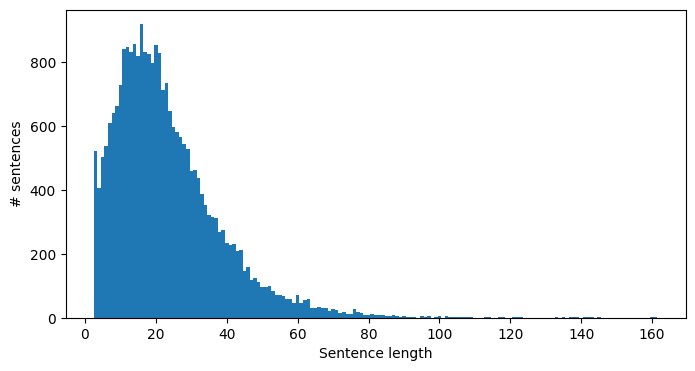

In [ ]:
l = np.asarray([len(x) for x in X], dtype=int)
plt.figure(figsize=(8, 4))
x = np.unique(l)
plt.bar(x, [np.sum(l==e) for e in x], width=1)
plt.xlabel("Sentence length")
plt.ylabel("# sentences")
plt.show()

In [ ]:
# We printed part of the vocabulary to make sure the word to index mapping was created correctly and contains real tokens from the training data.

tokens = {token for sentence in X_train for token in sentence}
idx2token = list(tokens)
idx2token.insert(0, '<UNK>')
idx2token.append('<PAD>')
token2idx = {token:idx for idx, token in enumerate(idx2token)}

tags = {tag for tags in y_train for tag in tags}
idx2tag = list(tags)
idx2tag.append('<PAD>')
tag2idx = {tag:idx for idx, tag in enumerate(idx2tag)}

print(idx2token[:15])
print(idx2tag)

['<UNK>', 'fábulas', 'Agosto', 'continue', 'llodos', '4g', 'E69', 'Newer', 'cuádruples', 'sofocantes', 'digo', 'Scotiabank', 'Tolkien', '12/km', 'n.']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, '<PAD>']


In [ ]:
def pad_and_encode(sentences, labels):
  assert len(sentences)==len(labels)
  assert np.all([len(sentence)==len(tags) for sentence, tags in zip(sentences, labels)])

  max_sentence_length = np.max([len(sentence) for sentence in sentences]) # Find out how much to pad
  padded_sentences = torch.zeros(len(sentences), max_sentence_length,     # Create data structures with <PAD> as default
                                 dtype=torch.long)
  padded_sentences[:] = token2idx['<PAD>']
  padded_labels = torch.zeros(len(sentences), max_sentence_length,
                              dtype=torch.long)
  padded_labels[:] = tag2idx['<PAD>']

  for i, (sentence, tags) in enumerate(zip(sentences, labels)):               # Loop over the data
    for j, token in enumerate(sentence):
      if token in token2idx.keys():
        padded_sentences[i, j] = token2idx[token]
      else:
        padded_sentences[i, j] = token2idx['<UNK>']
    for j, tag in enumerate(tags):
      padded_labels[i, j] = tag2idx[tag]
  return padded_sentences, padded_labels

a, b = pad_and_encode(X_train[:5], y_train[:5])
print(a)
print(b)

tensor([[37320, 34514, 33732, 53325, 36369, 50439, 40546, 36439, 37470, 38566,
         47679, 27142, 34294, 38566, 32438, 34294, 30391,   660, 54770, 43199,
         15620, 34294, 29268, 41281, 49642, 54199, 36369, 50330, 36439, 37470,
         54770, 13326, 34294, 32862, 57698, 41281, 48887, 34246, 46201, 25718,
         20721, 41281, 24505, 41281, 53325, 53320, 27290, 30922, 19775, 27717,
         54199, 36369, 57704, 48887, 60009],
        [17031,  1546, 44926, 48181,  3262, 23658, 22513, 42812, 29317, 16184,
         25907, 53334, 11359, 21195, 22513, 45255, 25128, 18129,  7197, 60009,
         60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284,
         60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284,
         60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284,
         60284, 60284, 60284, 60284, 60284],
        [20092,  5018, 55341,   660, 60259, 41554, 19775, 33561, 53320, 25709,
         27509, 60009, 60284, 60284, 6028

In [ ]:
def batch_iterator(sentences, labels, batch_size=64):
  """Helper function for iterating over batches of the data"""
  assert len(sentences) == len(labels)
  for i in range(0, len(sentences), batch_size):
    X, y = pad_and_encode(sentences[i:min(i+batch_size, len(sentences))],
                          labels[i:min(i+batch_size, len(sentences))])
    if torch.cuda.is_available():                                               # Move data to the GPU, if possible, before yielding it
      yield (X.cuda(), y.cuda())
    else:
      yield (X, y)

next(batch_iterator(X_train, y_train, batch_size=5))

(tensor([[37320, 34514, 33732, 53325, 36369, 50439, 40546, 36439, 37470, 38566,
          47679, 27142, 34294, 38566, 32438, 34294, 30391,   660, 54770, 43199,
          15620, 34294, 29268, 41281, 49642, 54199, 36369, 50330, 36439, 37470,
          54770, 13326, 34294, 32862, 57698, 41281, 48887, 34246, 46201, 25718,
          20721, 41281, 24505, 41281, 53325, 53320, 27290, 30922, 19775, 27717,
          54199, 36369, 57704, 48887, 60009],
         [17031,  1546, 44926, 48181,  3262, 23658, 22513, 42812, 29317, 16184,
          25907, 53334, 11359, 21195, 22513, 45255, 25128, 18129,  7197, 60009,
          60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284,
          60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284,
          60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284, 60284,
          60284, 60284, 60284, 60284, 60284],
         [20092,  5018, 55341,   660, 60259, 41554, 19775, 33561, 53320, 25709,
          27509, 60009, 6028

In [ ]:
class RNNTagger_spen(nn.Module):
  def __init__(self, word_embedding_dim, hidden_dim, vocabulary_size, tagset_size, dropout = 0.0, bidirectional = True): # we will change the model we want to use here

    super(RNNTagger_spen, self).__init__()
                                                                    # We need to initialise the class we are inheriting from
    self.hidden_dim_ = hidden_dim
    self.bidirectional = bidirectional
    self.dropout = dropout
    # this is the way that dropout is implememted in the manual
    self.m = nn.Dropout(p=dropout)

    if self.bidirectional == True:
      D = 2
    else:
      D = 1

                                                                                      # This simply stores the parameters
    self.vocabulary_size_ = vocabulary_size
    self.tagset_size_ = tagset_size
    self.batch_size = 256                                                                # Define the size of each batch

    self._word_embedding = nn.Embedding(num_embeddings=vocabulary_size,         # Creates the vector space for the input words
                                         embedding_dim=word_embedding_dim,
                                         padding_idx=token2idx['<PAD>'])


    self._rnn = nn.LSTM(
    input_size=word_embedding_dim,
    hidden_size=hidden_dim,
    batch_first=True,
    bidirectional=self.bidirectional)


    # Here we add the branching for the model to have the two possibilities, that we will chose from
    # also we need to assign if we want bidirectionality or not giving it true or false

    self._fc = nn.Linear(hidden_dim * D, tagset_size)                          # The linear layer maps from the RNN output space to tag space
    self._softmax = nn.LogSoftmax(dim=1)                                        # Softmax of outputting PDFs over tags

    self.training_loss_ = list()                                                # For plotting
    self.training_accuracy_ = list()

    if torch.cuda.is_available():                                               # Move the model to the GPU (if we have one)
      self.cuda()

  def forward(self, padded_sentences):
    """The forward pass through the network"""
    batch_size, max_sentence_length = padded_sentences.size()

    embedded_sentences = self._word_embedding(padded_sentences)                 # Sentences encoded as integers are mapped to vectors
    dropout_embedded = self.m(embedded_sentences)                               # Dropout is applied to the matrix space of the embbeded values

    sentence_lengths = (padded_sentences!=token2idx['<PAD>']).sum(dim=1)        # Find the length of sentences
    sentence_lengths = sentence_lengths.long().cpu()                            # Ensure the correct format
    X = nn.utils.rnn.pack_padded_sequence(dropout_embedded, sentence_lengths, # Pack the embedded data
                                          batch_first=True, enforce_sorted=False)
    rnn_out, _ = self._rnn(X)                                                   # Run the LSTM layer
    X, _ = nn.utils.rnn.pad_packed_sequence(rnn_out, batch_first=True)         # Unpack the output from the LSTM

    X = X.contiguous().view(-1, X.shape[2])                                     # The output from the LSTM layer is flattened
    dropout_hidden = self.m(X)                                                  # Dropout is applied to the flattened output
    tag_space = self._fc(dropout_hidden )                                       # Fully connected layer

    tag_scores = self._softmax(tag_space)                                       # Softmax is applied to normalise the outputs
    return tag_scores.view(batch_size, max_sentence_length, self.tagset_size_)


  def fit(self, X_train, y_train):
    loss_function = nn.NLLLoss(ignore_index=tag2idx['<PAD>'])                   # A loss function that fits our choice of output layer and data. The
                                                                                # loss function will ignore the padding index in the targets.
    optimizer = torch.optim.Adam(self.parameters(), lr=0.01)                   # We give the optimiser the parameters to work with, note that we can choose to only give some parameters

    for epoch in range(5):                                                          # Times to loop over the full dataset
      with tqdm(batch_iterator(X_train, y_train, batch_size=self.batch_size),
            total=len(X_train)//self.batch_size +1, unit="batch", desc="Epoch %i" % epoch) as batches:
        for inputs, targets in batches:                                             # Loop once over the training data
          self.zero_grad()                                                         # Reset gradients
          scores = self(inputs)                                                    # Forward pass
          loss = loss_function(scores.view(-1, self.tagset_size_),                 # Get loss, the data is reshaped as a long line of predictions and targets
                           targets.view(-1))
          loss.backward()                                                           # Backpropagate the error
          optimizer.step()                                                          # Run the optimizer to change the weights w.r.t the loss
          predictions = scores.argmax(dim=2, keepdim=True).squeeze()                # Calculate the batch training accuracy
          mask = targets!=tag2idx['<PAD>']                                          # Create a mask for ignoring <PAD> in the targets
          correct = (predictions[mask] == targets[mask]).sum().item()               # Item pulls the value from the GPU automatically (if needed)
          accuracy = correct / mask.sum().item()*100
          self.training_accuracy_.append(accuracy)                                 # Save the accuracy for plotting
          self.training_loss_.append(loss.item())                                  # Save the loss for plotting
          batches.set_postfix(loss=loss.item(), accuracy=accuracy)


  def score(self, X_test, y_test):
    with torch.no_grad():                                                           # Do not use the following forward passes to calculate a gradient
      n_correct = 0
      n_total = 0
      for inputs, targets in batch_iterator(X_test, y_test, batch_size= self.batch_size): # Loop once over the test data
        scores = self(inputs)                                                      # Runs the test data through the model
        predictions = scores.argmax(dim=2, keepdim=True).squeeze()                  # Finds the predictions
        mask = targets!=tag2idx['<PAD>']                                            # Create a mask for ignoring <PAD> in the targets
        n_correct += (predictions[mask] == targets[mask]).sum().item()              # Sums the number of correct predictions
        n_total += mask.sum().item()
    accuracy = 100 * n_correct / n_total
    return accuracy


model2 = RNNTagger_spen(word_embedding_dim=32,                                       # Dimensionality of the work embedding
                   hidden_dim=64,                                               # Dimensionality of the hidden state in the LSTM
                   vocabulary_size=len(token2idx),                              # The vocabulary incudes both the 'padding' and 'unknown' symbols
                   tagset_size=len(tag2idx)-1)


print(model2)

RNNTagger_spen(
  (m): Dropout(p=0.0, inplace=False)
  (_word_embedding): Embedding(60285, 32, padding_idx=60284)
  (_rnn): LSTM(32, 64, batch_first=True, bidirectional=True)
  (_fc): Linear(in_features=128, out_features=18, bias=True)
  (_softmax): LogSoftmax(dim=1)
)


In [ ]:
model2.fit(X_train, y_train)
model2.score(X_test, y_test)

train_acc = model2.score(X_train, y_train)
test_acc = model2.score(X_test, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

results.append({"language": "sp + en",
                "Model": "lstm",
                "bidirectional": True,
                "tagset": "UPOS",
                "masking": False,
                "dropout": 0.0,
                "Accuracy": test_acc
                })

Epoch 4: 100%|██████████| 90/90 [01:18<00:00,  1.14batch/s, accuracy=98, loss=0.073]


Train accuracy: 97.98356313707777
Test accuracy: 90.79276115875481


In [ ]:
embeddings = model2._word_embedding.weight.detach().cpu().numpy()
nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(embeddings)

# I had to run multiple word checking to see how it actually performed
words = ["want", "pero"]

for word in words:
    idx = token2idx[word]
    embedding = embeddings[idx]

    distances, indices = nbrs.kneighbors([embedding])

    print("\nWord:", word)
    print("Closest words:")

    for neighbor_idx in indices[0]:
        print(idx2token[neighbor_idx])

<class 'torch.nn.parameter.Parameter'>
torch.Size([60382, 32])

Word: want
Closest words:
want
promised
buscando
conflict
lashed
excreción
focusing
dijo
helping
distant

Word: pero
Closest words:
pero
servidor
but
hienas
dudaba
extras
Cossío
salvador
palmesana
onesie

Word: estar
Closest words:
estar
Usera
detonated
aprobar
existed
shark
Barno
asaltado
pintar
Zhougu


The nearest neighbours of "want" include several verbs such as promised, helping, focusing, and lashed, suggesting that the embedding space captures syntactic similarity between words that occupy similar grammatical roles. Interestingly, the Spanish verbs buscando and dijo also appear among the neighbours, indicating that the model learns cross-lingual similarities when words occur in similar contexts. A similar pattern appears with the Spanish conjunction pero, which retrieves the English conjunction but among its nearest neighbours. This suggests that the embedding space partially captures distributional similarity across languages. However, many neighbours remain noisy, which is expected since the model is run for POS tagging rather than semantic representation learning. This would be disccused in further work

## 11. Table Results:

The following table summarizes the accuracy results for all model configurations across the evaluated languages.
The results compare the majority baseline with GRU and LSTM models under different settings, including bidirectionality, masking, and dropout.
A simple pandas table was not able to capture the structure

In [ ]:
results_table = pd.DataFrame(results)
final_table = results_table.pivot_table(
    values="Accuracy",
    index="language",
    columns=["Model", "tagset", "masking","bidirectional", "dropout"])

print("\nFinal Results Table:")
print(final_table)


Final Results Table:
Model         Majority Baseline        gru                  lstm             \
tagset                     UPOS       UPOS                  UPOS              
masking                   False      False                 False              
bidirectional             False      False      True       False      True    
dropout                     0.0        0.0        0.0        0.0        0.0   
language                                                                      
en                    16.680373  87.992840  91.345363  89.226453  92.951478   
eu                    25.016949  83.633898  77.423729  78.332203  83.593220   
fi                    27.823558  76.890451  84.991517  85.179350  85.555017   
ja                    29.636887  88.880044  94.440022  91.629416  94.115486   
la                    20.286509  86.017877  88.385722  89.995856  89.439413   
ru                    24.591344  93.328993  92.675599  92.683595  93.812184   
sp                    17.39683

##  12. Results Analysis

In [ ]:
# Ensure accuracy is numeric
results_table["Accuracy"] = pd.to_numeric(results_table["Accuracy"], errors="coerce")

# Remove NaNs
df = results_table.dropna(subset=["Accuracy"]).copy()


df["Label"] = (
    df["language"] + " | " +
    df["Model"] +
    " | bi=" + df["bidirectional"].astype(str) +
    " | tag=" + df["tagset"] +
    " | mask=" + df["masking"].astype(str) +
    " | drop=" + df["dropout"].astype(str)
)


top10 = df.sort_values("Accuracy", ascending=False).head(10)

# Remove baseline models
df_no_baseline = df[df["Model"] != "Majority Baseline"]

worst10 = df_no_baseline.sort_values("Accuracy", ascending=True).head(10)

# Sort for nicer plots
top10 = top10.sort_values("Accuracy")
worst10 = worst10.sort_values("Accuracy")


The following plot shows the top 10 best performing model configurations across all experiments.
Each label indicates the language and the model settings used (model type, bidirectionality, tagset, masking, and dropout).
This visualization highlights which combinations of architecture and language achieved the highest tagging accuracy.

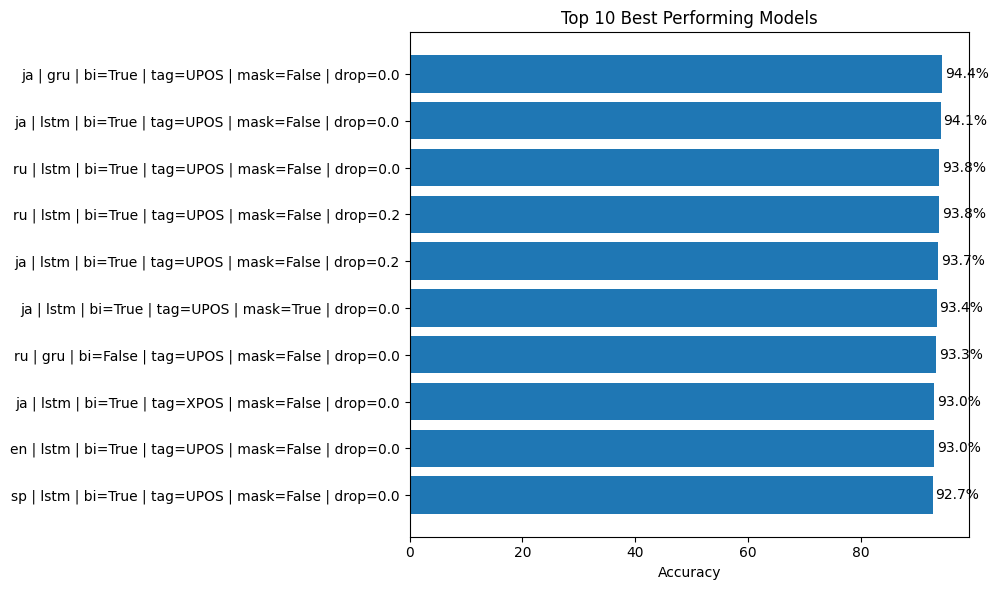

In [ ]:
plt.figure(figsize=(10,6))

labels = top10["Label"]
values = top10["Accuracy"]

plt.barh(labels, values)

for i, acc in enumerate(values):
    plt.text(acc + 0.5, i, f"{acc:.1f}%", va="center")

plt.title("Top 10 Best Performing Models")
plt.xlabel("Accuracy")

plt.tight_layout()
plt.show()


This plot shows the 10 worst performing model configurations in the experiments.
It helps identify which combinations of language and model settings produced lower tagging accuracy,
providing a contrast with the best performing configurations shown previously.

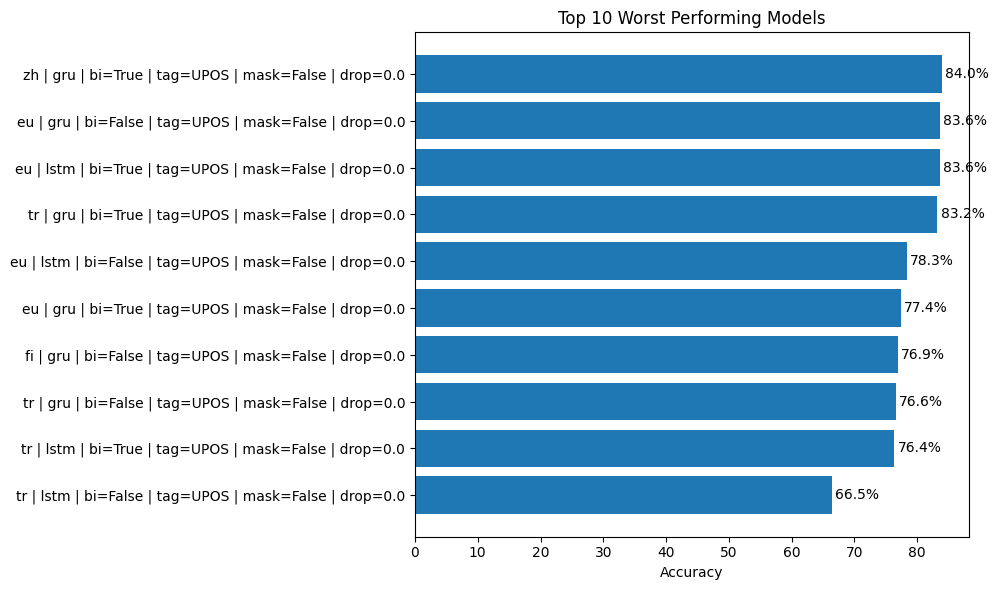

In [ ]:
plt.figure(figsize=(10,6))

labels = worst10["Label"]
values = worst10["Accuracy"]

plt.barh(labels, values)

for i, acc in enumerate(values):
    plt.text(acc + 0.5, i, f"{acc:.1f}%", va="center")

plt.title("Top 10 Worst Performing Models")
plt.xlabel("Accuracy")

plt.tight_layout()
plt.show()


This plot compares the performance of the majority baseline, LSTM, and GRU models across all evaluated languages.
It shows that the neural models perform much better than the baseline in every language.
The plot also allows us to observe how model performance varies between languages.

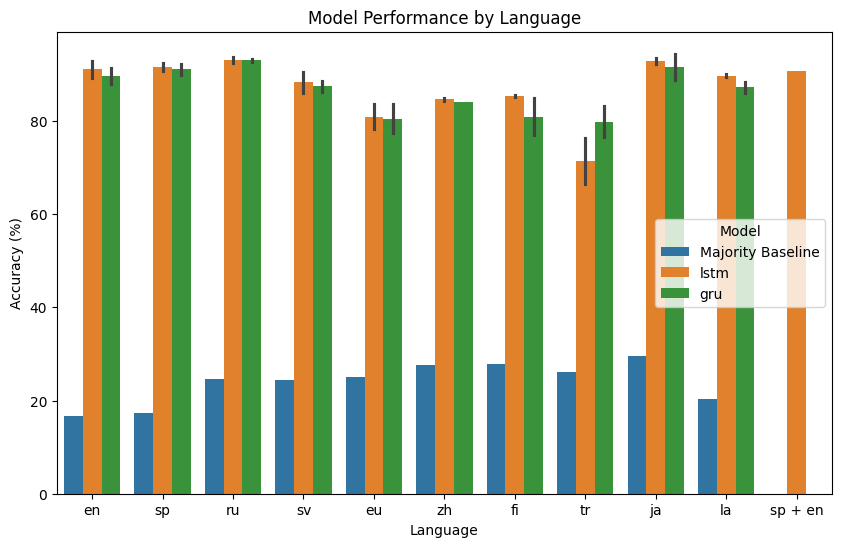

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_table,
    x="language",
    y="Accuracy",
    hue="Model"
)

plt.title("Model Performance by Language")
plt.ylabel("Accuracy (%)")
plt.xlabel("Language")
plt.legend(title="Model")

plt.show()

This plot shows the effect of using bidirectional RNN layers compared to unidirectional ones across different languages.
In most cases, bidirectional models achieve higher accuracy because they can use context from both directions in the sentence.

The black lines show how much the results vary between different model settings.
Longer lines mean the results change more between configurations, while shorter lines mean the results are more stable.

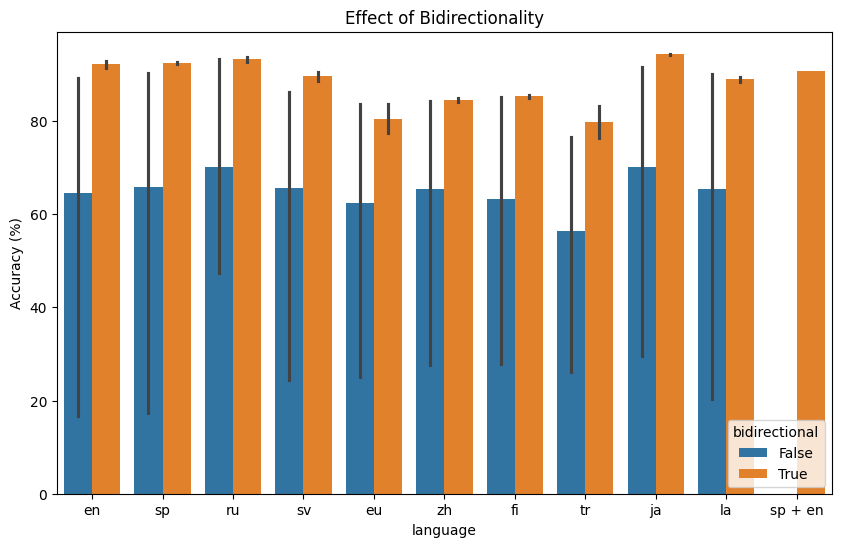

In [ ]:
bidirectional_data = results_table[
    (results_table["masking"] == False) &
    (results_table["dropout"] == 0.0) &
    (results_table["tagset"] == "UPOS")
]

plt.figure(figsize=(10,6))

sns.barplot(
    data=bidirectional_data,
    x="language",
    y="Accuracy",
    hue="bidirectional"
)

plt.title("Effect of Bidirectionality")
plt.ylabel("Accuracy (%)")

plt.show()

 ## 13. Discussion


The results show a clear improvement when using neural models compared to the majority baseline (which is expected as it is greedy assigning the most frequent tag to everything). While the baseline achieves between roughly 16% and 30% accuracy depending on the language, the GRU and LSTM models consistently reach values between approximately 80% and 95%. This large difference shows the importance of contextual information for POS tagging, which simple baseline models cannot capture.

One of the most consistent patterns in the results is the improvement obtained when using bidirectional recurrent layers. In most languages the bidirectional versions of both GRU and LSTM models outperform their unidirectional counterparts. This is expected, since bidirectional models can use information from both the left and right context of a word, which is particularly useful for POS tags.

The comparison between GRU and LSTM architectures shows relatively small differences in performance. In several cases GRU slightly outperforms LSTM, while in others the opposite occurs despite lstm being slightly better than GRU. Overall, both architectures produce very similar results, suggesting that the simpler GRU architecture can achieve comparable performance.

The results also show differences between languages. Languages such as Japanese and Russian achieve some of the highest accuracies, reaching around 94%. In contrast, languages such as Turkish, Basque and Finnish show lower performance. This is likely related to linguistic structure, since these languages are more morphologically complex and often considered agglutinative, meaning that words can contain many morphemes. This could increases the variability of tokens and makes POS tagging more difficult for the model.

Experiments with dropout and masking show relatively small changes in performance. Masking slightly encourages the model to rely more on contextual information rather than memorizing specific tokens, while dropout helps regularize the model and reduce overfitting. However, these effects are smaller than those observed from architectural choices such as bidirectionality.

Finally, the comparison between UPOS and XPOS tagsets shows that UPOS generally achieves slightly higher accuracy. This is expected since UPOS is a smaller and more general tagset, whereas XPOS contains more detailed language-specific tags, making the classification task more complex, more languages should be considered in order to draw any conclusion.